## Resume Screening and Candidate Selection Model

### 1. Business Problem


Recruiters receive a large number of resumes for each job, making manual screening slow, inconsistent, and error-prone. An automated system is needed to quickly filter resumes, identify suitable candidates, and improve hiring efficiency.

### 2. Project Goal

Build a Machine Learning model that:

It takes resume data as input Analyzes skills, experience, keywords Predicts whether a candidate should be shortlisted or not

Output: 1 then Selected 0 then Rejected

### Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

### load dataset

In [2]:
df = pd.read_csv(r"C:\Users\VARSHA SURA\Downloads\resume_dataset_200k_enhanced.csv")
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

candidate_id             0
age                      0
education_level          0
university_tier          0
cgpa                     0
internships              0
projects                 0
programming_languages    0
certifications           0
experience_years         0
hackathons               0
research_papers          0
skills_score             0
hired                    0
soft_skills_score        0
resume_length_words      0
company_type             0
dtype: int64

In [5]:
df['hired'].value_counts()

hired
1    141212
0     58788
Name: count, dtype: int64

In [6]:
df.shape

(200000, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  object 
 3   university_tier        200000 non-null  object 
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-nu

### data preprocessing

In [8]:
df.drop(columns=['candidate_id'], inplace=True)

In [9]:
df.drop(columns=['company_type'],inplace=True)

In [10]:
df['education_level'].unique()

array(['Bachelors', 'Masters', 'PhD'], dtype=object)

In [11]:
df['university_tier'].unique()

array(['Tier 2', 'Tier 3', 'Tier 1'], dtype=object)

In [12]:
encoder = OrdinalEncoder(categories=[['Bachelors', 'Masters', 'PhD']])
df['education_level'] = encoder.fit_transform(df[['education_level']])

In [13]:
encoder = OrdinalEncoder(categories=[['Tier 3', 'Tier 2', 'Tier 1']])
df['university_tier'] = encoder.fit_transform(df[['university_tier']])

In [14]:
df['education_level']=df['education_level'].astype('int')

In [15]:
df['university_tier']=df['university_tier'].astype('int')

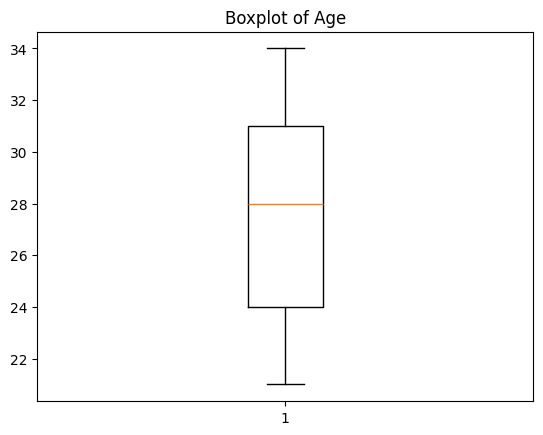

In [16]:
import matplotlib.pyplot as plt
plt.boxplot(df['age'])
plt.title("Boxplot of Age")
plt.show()

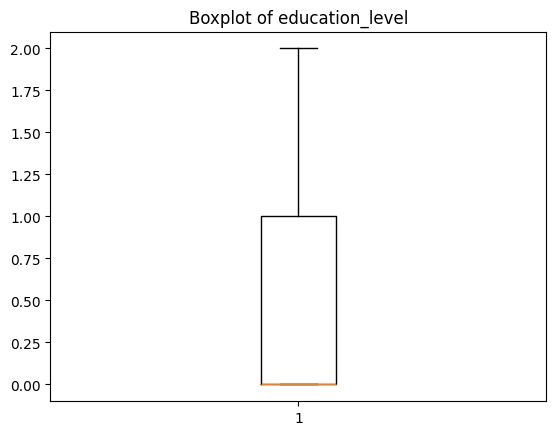

In [17]:
plt.boxplot(df['education_level'])
plt.title("Boxplot of education_level")
plt.show()

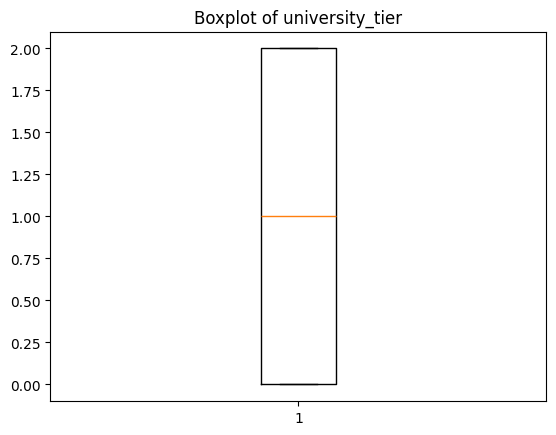

In [18]:
plt.boxplot(df['university_tier'])
plt.title("Boxplot of university_tier")
plt.show()

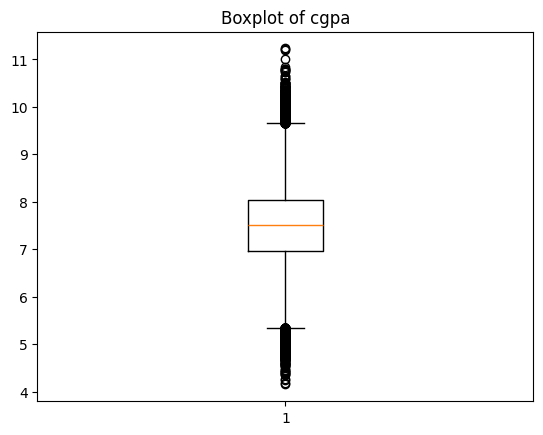

In [19]:
plt.boxplot(df['cgpa'])
plt.title("Boxplot of cgpa")
plt.show()

In [20]:
df['cgpa'].unique()

array([ 8.16,  6.35,  7.78,  6.92,  8.24,  7.24,  6.96,  7.09,  7.02,
        7.4 ,  5.8 ,  6.51,  8.07,  7.28,  6.11,  6.19,  8.  ,  6.82,
        7.93,  7.68,  5.94,  7.99,  6.93,  8.58,  5.09,  6.32,  7.95,
        6.54,  8.47,  8.41,  6.45,  8.09,  7.25,  8.12,  7.71,  7.42,
        6.76,  6.44,  7.69,  7.48,  7.27,  6.25,  8.22,  8.67,  5.58,
        6.18,  7.15,  7.1 ,  6.55,  6.83,  7.44,  8.36,  6.86,  7.59,
        8.05,  8.14,  7.5 ,  8.5 ,  9.25,  9.33,  7.18,  7.3 ,  6.89,
        6.67,  8.91,  6.68,  7.8 ,  7.91,  7.65,  7.66,  7.05,  8.64,
        6.99,  7.31,  7.46,  8.46,  6.63,  7.85,  7.6 ,  7.61,  8.66,
        8.28,  7.52,  6.36,  8.21,  8.51,  7.7 ,  8.33,  7.82,  7.22,
        7.98,  7.73,  7.06,  6.79,  7.16,  8.2 ,  8.35,  6.69,  6.73,
        7.41,  5.91,  8.23,  8.81,  7.86,  6.91,  7.29,  7.83,  6.66,
        8.82,  8.18,  6.95,  9.08,  8.59,  7.79,  8.17,  8.43,  6.41,
        8.31,  8.25,  8.48,  7.97,  7.45,  7.12,  5.78,  6.98,  7.49,
        8.1 ,  7.43,

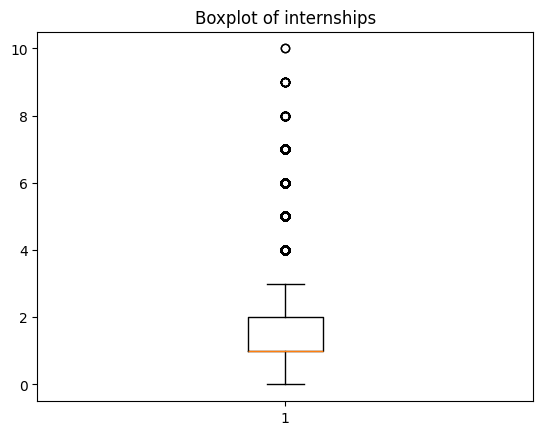

In [21]:
plt.boxplot(df['internships'])
plt.title("Boxplot of internships")
plt.show()

In [22]:
df['internships'].unique()

array([ 2,  3,  0,  1,  6,  4,  5,  7,  8,  9, 10])

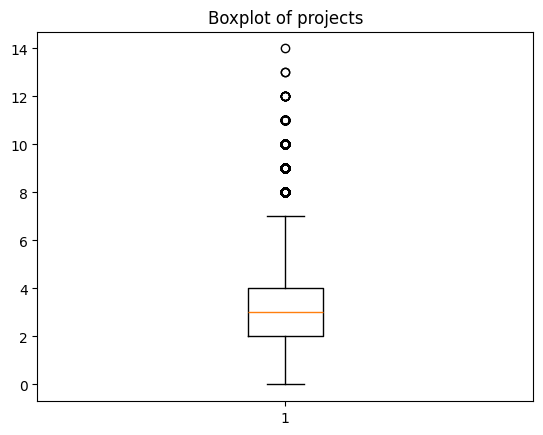

In [23]:
plt.boxplot(df['projects'])
plt.title("Boxplot of projects")
plt.show()

In [24]:
df['projects'].unique()

array([ 7,  2,  1,  0,  5,  4,  3,  6,  8,  9, 10, 11, 14, 12, 13])

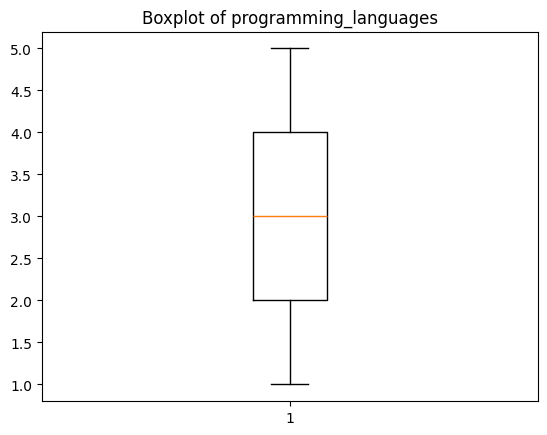

In [25]:
plt.boxplot(df['programming_languages'])
plt.title("Boxplot of programming_languages")
plt.show()

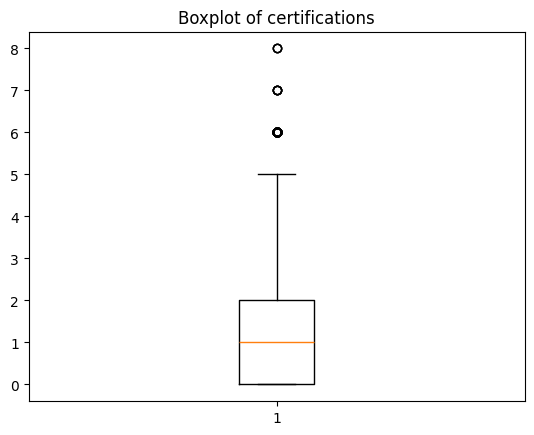

In [26]:
plt.boxplot(df['certifications'])
plt.title("Boxplot of certifications")
plt.show()

In [27]:
df['certifications'].unique()

array([2, 1, 0, 5, 3, 4, 6, 7, 8])

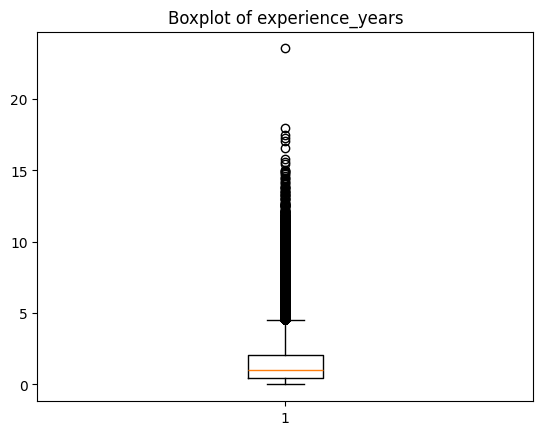

In [28]:
plt.boxplot(df['experience_years'])
plt.title("Boxplot of experience_years")
plt.show()

In [29]:
df['experience_years'].unique()

array([ 0.33,  4.99,  0.93, ..., 17.95, 13.2 , 11.44], shape=(1183,))

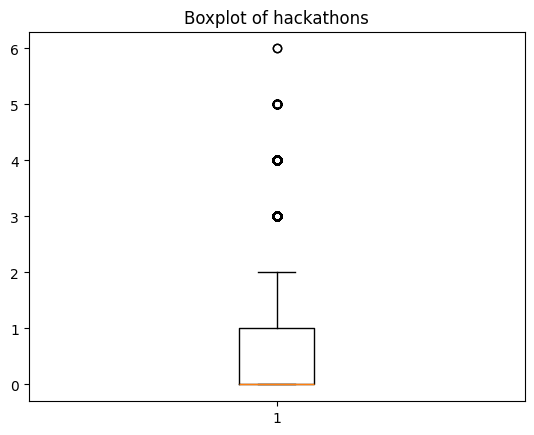

In [30]:
plt.boxplot(df['hackathons'])
plt.title("Boxplot of hackathons")
plt.show()

In [31]:
df['hackathons'].unique()

array([0, 2, 1, 3, 5, 4, 6])

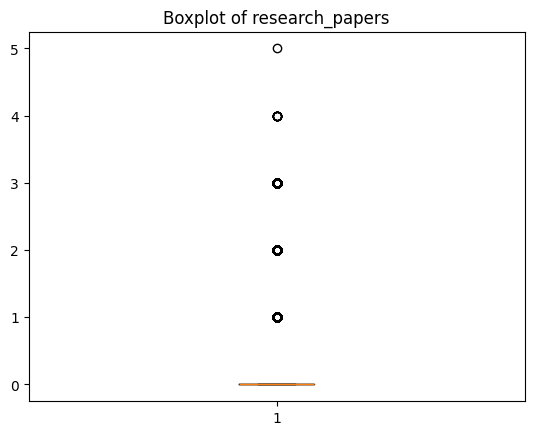

In [32]:
plt.boxplot(df['research_papers'])
plt.title("Boxplot of research_papers")
plt.show()

In [33]:
df['research_papers'].unique()

array([0, 1, 2, 3, 4, 5])

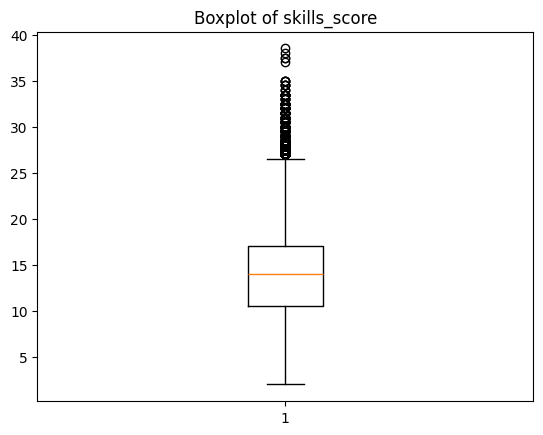

In [34]:
plt.boxplot(df['skills_score'])
plt.title("Boxplot of skills_score")
plt.show()

In [35]:
df['skills_score'].unique()

array([21. , 11. , 15. , 11.5,  5. , 15.5, 18. , 10.5, 17.5, 13.5, 10. ,
       20.5, 17. , 19. , 12. ,  7. , 12.5, 29. , 13. , 14. ,  8. , 16. ,
       20. , 16.5,  8.5, 23. , 22.5, 14.5,  6. , 22. , 18.5, 23.5,  9.5,
       19.5,  7.5,  4. , 29.5,  5.5, 24. ,  9. , 21.5,  2. , 25.5, 25. ,
       28. , 31. ,  3. , 26. , 26.5,  6.5, 27.5, 24.5,  3.5, 28.5, 27. ,
        4.5, 30. , 30.5, 33. , 31.5, 32.5, 34.5, 35. , 32. , 33.5, 37.5,
       34. , 38.5, 37. , 38. ])

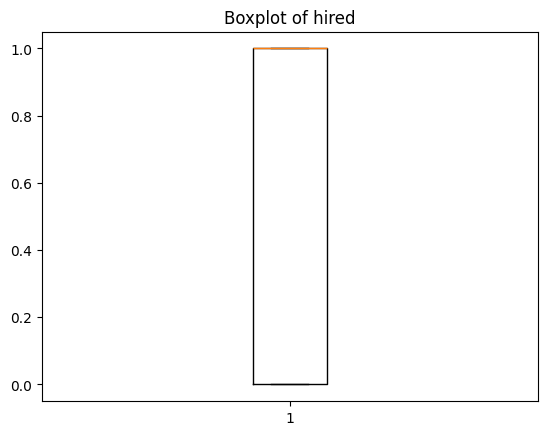

In [36]:
plt.boxplot(df['hired'])
plt.title("Boxplot of hired")
plt.show()

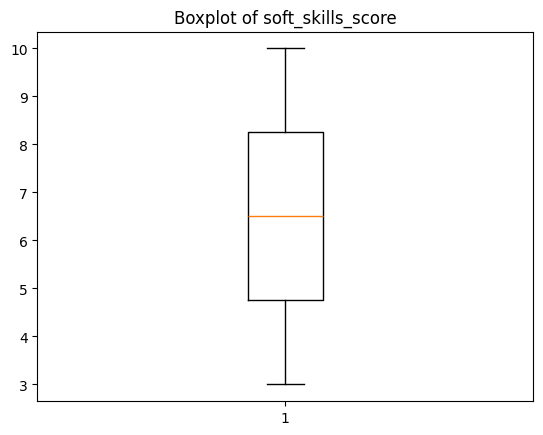

In [37]:
plt.boxplot(df['soft_skills_score'])
plt.title("Boxplot of soft_skills_score")
plt.show()

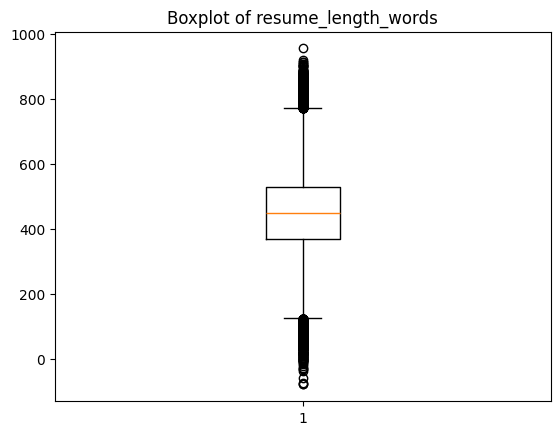

In [38]:
plt.boxplot(df['resume_length_words'])
plt.title("Boxplot of resume_length_words")
plt.show()

In [39]:
df['resume_length_words'].unique()

array([409, 237, 435, 340, 371, 345, 571, 443, 414, 455, 386, 321, 431,
       294, 499, 297, 308, 633, 505, 163, 477, 607, 614, 496, 635, 685,
       436, 539, 290, 556, 535, 449, 577, 569, 338, 474, 413, 599, 684,
       595, 339, 403, 398, 582, 336, 364, 472, 676, 626, 513, 347, 501,
       573, 610, 616, 625, 557, 510, 531, 634, 532, 362, 547, 314, 453,
       315, 586, 507, 561, 523, 408, 517, 471, 437, 416, 385, 503, 389,
       512, 534, 704, 541, 266, 590, 508, 613, 522, 456, 473, 470, 447,
       583, 552, 446, 422, 372, 332, 528, 480, 509, 671, 272, 788, 441,
       481, 360, 254, 574, 650, 368, 629, 636, 502, 511, 375, 490, 514,
       334, 406, 402, 466, 246, 489, 619, 179, 426, 293, 384, 281, 419,
       353, 451, 367, 465, 581, 594, 442, 232, 369,  77, 301, 394, 275,
       500, 601, 170, 759, 747, 592, 423, 433, 352, 184, 395, 494, 678,
       478, 412, 565, 196, 450, 357, 391, 104, 484, 382, 427, 568, 632,
       212, 231, 392, 559, 461, 288, 383, 355, 459, 289, 192, 35

In [40]:
df = df[df['resume_length_words'] >= 0]

In [41]:
df['resume_length_words'].unique()

array([409, 237, 435, 340, 371, 345, 571, 443, 414, 455, 386, 321, 431,
       294, 499, 297, 308, 633, 505, 163, 477, 607, 614, 496, 635, 685,
       436, 539, 290, 556, 535, 449, 577, 569, 338, 474, 413, 599, 684,
       595, 339, 403, 398, 582, 336, 364, 472, 676, 626, 513, 347, 501,
       573, 610, 616, 625, 557, 510, 531, 634, 532, 362, 547, 314, 453,
       315, 586, 507, 561, 523, 408, 517, 471, 437, 416, 385, 503, 389,
       512, 534, 704, 541, 266, 590, 508, 613, 522, 456, 473, 470, 447,
       583, 552, 446, 422, 372, 332, 528, 480, 509, 671, 272, 788, 441,
       481, 360, 254, 574, 650, 368, 629, 636, 502, 511, 375, 490, 514,
       334, 406, 402, 466, 246, 489, 619, 179, 426, 293, 384, 281, 419,
       353, 451, 367, 465, 581, 594, 442, 232, 369,  77, 301, 394, 275,
       500, 601, 170, 759, 747, 592, 423, 433, 352, 184, 395, 494, 678,
       478, 412, 565, 196, 450, 357, 391, 104, 484, 382, 427, 568, 632,
       212, 231, 392, 559, 461, 288, 383, 355, 459, 289, 192, 35

In [42]:
df['age'].skew()

np.float64(-0.0042237947756890125)

In [43]:
df['education_level'].skew()

np.float64(1.143284521200549)

In [44]:
df['university_tier'].skew()

np.float64(-0.0015734148726746125)

In [45]:
df['cgpa'].skew()

np.float64(-0.0009943337115636273)

In [46]:
df['internships'].skew()

np.float64(0.8177309129538505)

In [47]:
df['projects'].skew()

np.float64(0.5811573686978807)

In [48]:
df['programming_languages'].skew()

np.float64(-0.004774178060987671)

In [49]:
df['certifications'].skew()

np.float64(1.0030385130328874)

In [50]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df['certifications'] = pt.fit_transform(df[['certifications']])

In [51]:
df['certifications'].skew()

np.float64(0.03343331782324657)

In [52]:
df['experience_years'].skew()

np.float64(2.0232098496234507)

In [53]:
pt = PowerTransformer(method='yeo-johnson')
df['experience_years'] = pt.fit_transform(df[['experience_years']])

In [54]:
df['hackathons'].skew()

np.float64(1.4285479112858188)

In [55]:
pt = PowerTransformer(method='yeo-johnson')
df['hackathons'] = pt.fit_transform(df[['hackathons']])

In [56]:
df['research_papers'].skew()

np.float64(2.2146871532563353)

In [57]:
pt = PowerTransformer(method='yeo-johnson')
df['research_papers'] = pt.fit_transform(df[['research_papers']])

In [58]:
df['skills_score'].skew()

np.float64(0.24836589268062925)

In [59]:
df['hired'].value_counts()

hired
1    141197
0     58783
Name: count, dtype: int64

In [60]:
df['hired'].value_counts(normalize=True)

hired
1    0.706056
0    0.293944
Name: proportion, dtype: float64

In [61]:
df['hired'].unique()

array([1, 0])

In [62]:
from imblearn.over_sampling import SMOTE
X = df.drop('hired', axis=1)
y = df['hired']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [63]:
df['soft_skills_score'].skew()

np.float64(-0.0026224417668145156)

In [64]:
df['resume_length_words'].skew()

np.float64(-0.0047018963485486644)

## train and test

In [65]:
X = df.drop('hired', axis=1)
y = df['hired']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Models

In [67]:
## Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_predlr = model.predict(X_test)

In [68]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [69]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [70]:
# knn
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=5)
kn.fit(X_train, y_train)
y_pred_kn=kn.predict(X_test)

In [71]:
print("Logistic Regression:", accuracy_score(y_test, y_predlr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_kn))


Logistic Regression: 0.7078707870787079
Decision Tree: 0.5797329732973298
Random Forest: 0.7042204220422043
KNN: 0.643964396439644


In [72]:
print("random forest Report:\n")
print(classification_report(y_test, y_pred_rf))

random forest Report:

              precision    recall  f1-score   support

           0       0.32      0.01      0.02     11684
           1       0.71      0.99      0.83     28312

    accuracy                           0.70     39996
   macro avg       0.52      0.50      0.42     39996
weighted avg       0.60      0.70      0.59     39996



In [73]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
print("\nlogistic regression Report:\n")
print(classification_report(y_test, y_predlr))


logistic regression Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     11684
           1       0.71      1.00      0.83     28312

    accuracy                           0.71     39996
   macro avg       0.35      0.50      0.41     39996
weighted avg       0.50      0.71      0.59     39996



C:\ANA\envs\computer_vision\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ANA\envs\computer_vision\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ANA\envs\computer_vision\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [76]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.6677917791779178


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Parameter space (small = fast)
param_dist = {
    "max_depth": [8, 10, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [1, 2]
}

# Randomized Search
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,     
    cv=2,      
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Train
search.fit(X_train, y_train)

# Best model
best_model = search.best_estimator_

print("Best Params:", search.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 12}


In [81]:
import pickle
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [83]:
import os
print(os.getcwd())

C:\Users\VARSHA SURA
